In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from scipy.optimize import least_squares

from portable_helpers import M_ogse_mixed_offset, M_ogse_free, _roi_color_map, DEFAULT_BRAIN_MARKERS

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

MASTER_PATH  = Path("../../analysis/brains/ogse_experiments/master.long.parquet")
OUT_DIR      = Path("../../analysis/brains/ogse_experiments/lab/fit_ogse_mixed_CC-a1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIRECTIONS  = ["tra", "long"]
N_LIST      = [4, 8]
TD_LIST     = None
# ROI_LIST
#    None → All ROIS
#    ["AntCC","MidAntCC","CentralCC","MidPostCC","PostCC"] → CC
#    ["Left-Lateral-Ventricle", "Right-Lateral-Ventricle"] → Ventricles
ROI_LIST    = ["AntCC","MidAntCC","CentralCC","MidPostCC","PostCC"]
G_COLUMN    = "g_thorsten"
G_CORRECTION_COLUMN = "grad_correction_factor"
Y_COLUMN    = "value"         # "value" (raw a.u.) or "value_norm" (normalized by S0)
D0_FIXED    = 3.2e-12         # m²/ms, fixed free-water diffusivity

# ── Correlation time tc ───────────────────────────────────────────────────────
TC_FIXED   = None             # None → fitted per curve; float → pinned [ms]; "master" → from master table
TC_INIT    = 2.0              # ms, initial guess for tc
TC_BOUNDS  = (0.05, 1000.0)  # (lower, upper) bounds in ms

# TC_GLOBAL: scope for a shared tc fit
#   None         → per-curve (one tc per td, N, direction)
#   "td"         → one tc per (subj, roi, direction, td), shared across N
#   "direction"  → one tc per (subj, roi, direction), shared across td & N
#   "roi"        → one tc per (subj, roi), shared across td, N & direction
#   "subj"       → one tc per subject, shared across all roi, td, N & direction
#   "all"        → one tc for all data
TC_GLOBAL = "direction"

TC_MASTER_COL = "tc_ms"       # master table column (used when TC_FIXED = "master")

# ── Tortuosity factor α ───────────────────────────────────────────────────────
ALPHA_FIXED  = None       # None → fitted per curve; float → pinned; "master" → from master table
ALPHA_INIT   = 0.5
ALPHA_BOUNDS = (0.0, 1.0)

# ALPHA_GLOBAL: scope for a shared α fit
#   None         → per-curve (one α per td, N, direction)
#   "direction"  → one α per (subj, roi, direction), shared across td & N
#   "td"         → one α per (subj, roi, direction, td), shared across N
#   "roi"        → one α per (subj, roi), shared across td, N & direction
#   "subj"       → one α per subject, shared across all roi, td, N & direction
#   "all"        → one α for all data
ALPHA_GLOBAL = "direction"

ALPHA_MASTER_COL = "alpha_macro"   # master table column (used when ALPHA_FIXED = "master")

# ── Model name ────────────────────────────────────────────────────────────────
MODEL_NAME = 'mixed'

# ── Rician noise floor RN (signal units) ─────────────────────────────────────
# Signal model:  S(G) = sqrt( M0² · S_mixed(tc, α, G)² + RN² )
#                where  M0 = sqrt(S0² − RN²),  RN always fixed.
# S0 is the measured signal at G ≈ 0; M0 is derived, not fitted.
#
#   None                        → no noise correction (RN = 0)
#   float                       → same RN for all subjects, td, and roi
#   {td: float}                 → fixed per td, same for all subjects and roi
#   {subj: float}               → fixed per subject, same for all td and roi
#   {subj: {td: float}}         → fixed per subject and td, same for all roi
#   {subj: {td: {roi: float}}}  → fixed per subject, td, and roi

RN_FIXED = {
    "BRAIN": {
        76.0:  {"AntCC": 37, "MidAntCC": 38, "CentralCC": 48, "MidPostCC": 49, "PostCC": 53},
        90.0:  {"AntCC": 32, "MidAntCC": 38, "CentralCC": 36, "MidPostCC": 42, "PostCC": 36},
        120.0: {"AntCC": 36, "MidAntCC": 44, "CentralCC": 40, "MidPostCC": 46, "PostCC": 40},
        143.4: {"AntCC": 36, "MidAntCC": 44, "CentralCC": 40, "MidPostCC": 46, "PostCC": 40},
        210.0: {"AntCC": 37, "MidAntCC": 38, "CentralCC": 48, "MidPostCC": 49, "PostCC": 53},
    },
    "LUDG": {
        90.0:  {"AntCC": 31, "MidAntCC": 35, "CentralCC": 38, "MidPostCC": 48, "PostCC": 49},
        120.0: {"AntCC": 30, "MidAntCC": 42, "CentralCC": 34, "MidPostCC": 44, "PostCC": 44},
        143.4: {"AntCC": 30, "MidAntCC": 42, "CentralCC": 34, "MidPostCC": 44, "PostCC": 44},
        210.0: {"AntCC": 31, "MidAntCC": 35, "CentralCC": 38, "MidPostCC": 48, "PostCC": 49},
    },
    "MBBL": {
        90.0:  {"AntCC": 35, "MidAntCC": 40, "CentralCC": 40, "MidPostCC": 52, "PostCC": 51},
        120.0: {"AntCC": 31, "MidAntCC": 41, "CentralCC": 47, "MidPostCC": 49, "PostCC": 44},
        143.4: {"AntCC": 31, "MidAntCC": 41, "CentralCC": 47, "MidPostCC": 49, "PostCC": 44},
        210.0: {"AntCC": 35, "MidAntCC": 40, "CentralCC": 40, "MidPostCC": 52, "PostCC": 51},
    },
}

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════

df = pd.read_parquet(MASTER_PATH)

data = df[
    (df.row_kind == "signal_rotated") &
    (df.direction.isin(DIRECTIONS)) &
    (df.N.isin(N_LIST)) &
    (df.stat == "avg")
].copy()

missing_cols = [c for c in [G_COLUMN, Y_COLUMN, G_CORRECTION_COLUMN] if c is not None and c not in data.columns]
if missing_cols:
    raise KeyError(f"Missing column(s): {missing_cols}")

data["G_fit"] = data[G_COLUMN]
if G_CORRECTION_COLUMN is not None:
    data["G_fit"] = data["G_fit"] * data[G_CORRECTION_COLUMN]
data["y_raw"] = data["value"]   # raw signal — always kept to derive S0
data["y_fit"] = data[Y_COLUMN]

G_LABEL = f"Modulation gradient G [mT/m] ({G_COLUMN})"
Y_LABEL = f"{Y_COLUMN} [a.u.]"

if TD_LIST is not None:
    data = data[data.td_ms.isin(TD_LIST)]
if ROI_LIST is not None:
    data = data[data.roi.isin(ROI_LIST)]

print(f"Rows loaded: {len(data)}")
print("Groups (subj, roi, dir):", data.groupby(["subj", "roi", "direction"]).ngroups)
print(f"Gradient column: {G_COLUMN}" + (f" × {G_CORRECTION_COLUMN}" if G_CORRECTION_COLUMN else ""))
print(f"Signal column:   {Y_COLUMN}")
data[["subj", "roi", "direction", "td_ms", "N", "G_fit", "y_fit"]]

Rows loaded: 2310
Groups (subj, roi, dir): 30
Gradient column: g_thorsten × grad_correction_factor
Signal column:   value


,subj,roi,direction,td_ms,N,G_fit,y_fit
31702,BRAIN,AntCC,tra,90.0,4,NaN,182.335020
31703,BRAIN,AntCC,tra,90.0,4,NaN,176.114604
31704,BRAIN,AntCC,tra,90.0,4,NaN,169.601916
31705,BRAIN,AntCC,tra,90.0,4,NaN,162.216931
31706,BRAIN,AntCC,tra,90.0,4,NaN,151.078714
...,...,...,...,...,...,...,...
176699,MBBL,PostCC,long,143.4,4,NaN,42.524331
176700,MBBL,PostCC,long,143.4,4,NaN,39.458824
176701,MBBL,PostCC,long,143.4,4,NaN,40.258252
176702,MBBL,PostCC,long,143.4,4,NaN,41.296240


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FIT FUNCTIONS
#
# Signal model:  S(G) = sqrt( M0² · S_mixed(tc, α, G)² + RN² )
#                where  M0 = sqrt(S0² − RN²),  RN always fixed.
#                tc and α are free or fixed per configuration.
# ══════════════════════════════════════════════════════════════════════════════

def _resolve_rn(subj, td, roi=None):
    # Return fixed RN for (subj, td, roi). Returns 0.0 when RN_FIXED is None.
    if RN_FIXED is None:
        return 0.0
    if isinstance(RN_FIXED, dict):
        first_key = next(iter(RN_FIXED))
        if isinstance(first_key, str):               # {subj: ...}
            subj_entry = RN_FIXED.get(subj)
            if subj_entry is None:
                return 0.0
            if isinstance(subj_entry, dict):         # {subj: {td: ...}}
                td_entry = subj_entry.get(float(td), subj_entry.get(td))
                if td_entry is None:
                    return 0.0
                if isinstance(td_entry, dict):       # {subj: {td: {roi: float}}}
                    return float(td_entry.get(roi, 0.0))
                return float(td_entry)               # {subj: {td: float}}
            return float(subj_entry)                 # {subj: float}
        return float(RN_FIXED.get(float(td), RN_FIXED.get(td, 0.0)))  # {td: float}
    return float(RN_FIXED)


def _m0_from_s0(s0_raw, rn):
    # M0 = sqrt(S0² − RN²). For value_norm returns M0/S0.
    m0 = np.sqrt(max(float(s0_raw)**2 - float(rn)**2, 0.0))
    if Y_COLUMN == "value_norm":
        return m0 / float(s0_raw) if float(s0_raw) > 0 else 1.0
    return m0


def _get_master_value(subj, roi, direction, col):
    # Look up a fixed value from the master table for one (subj, roi, direction) group.
    rows = df[(df.subj == subj) & (df.roi == roi) & (df.direction == direction)]
    if col in rows.columns and not rows[col].isna().all():
        return float(rows[col].dropna().iloc[0])
    raise KeyError(f"'{col}' not found or all-NaN for {subj}/{roi}/{direction}")


def _resolve_tc(subj, roi, direction):
    # Return fixed tc [ms] or None (→ to be fitted).
    if TC_FIXED is None:
        return None
    if TC_FIXED == "master":
        return _get_master_value(subj, roi, direction, TC_MASTER_COL)
    return float(TC_FIXED)


def _resolve_alpha(subj, roi, direction):
    # Return fixed α or None (→ to be fitted).
    if ALPHA_FIXED is None:
        return None
    if ALPHA_FIXED == "master":
        return _get_master_value(subj, roi, direction, ALPHA_MASTER_COL)
    return float(ALPHA_FIXED)


def _predict(td, G, N, tc, alpha, M0, rn):
    # S(G) = sqrt( (M0·S_mixed)² + RN² )
    with np.errstate(over="ignore", invalid="ignore"):
        sig = M_ogse_mixed_offset(td, G, N, td / N, tc, alpha, M0, D0_FIXED, 0, 0)
        return np.sqrt(sig**2 + rn**2) if rn != 0.0 else sig


def _param_stderr(result, param_idx):
    # 1-σ error on params[param_idx] from the least-squares Jacobian.
    dof = result.fun.size - result.x.size
    if dof <= 0 or result.x.size == 0 or param_idx >= result.x.size:
        return np.nan
    try:
        cov = np.linalg.pinv(result.jac.T @ result.jac) * (2.0 * result.cost / dof)
        return float(np.sqrt(max(float(cov[param_idx, param_idx]), 0.0)))
    except np.linalg.LinAlgError:
        return np.nan


def fit_curve(td, N, G, y, subj=None, roi=None, direction=None, s0=None):
    """Fit tc and/or α for ONE (td, N, direction) curve. Returns (tc, alpha, result).

    tc is optimised in log-space for numerical stability.
    When both tc and alpha are free: result.x = [log_tc, alpha].
    When only tc is free:            result.x = [log_tc].
    When only alpha is free:         result.x = [alpha].
    When neither is free:            result.x = [] (mock result, cost from residuals).
    """
    rn = _resolve_rn(subj, td, roi)
    M0 = _m0_from_s0(s0, rn) if s0 is not None else float(y.max())

    tc_fixed = _resolve_tc(subj, roi, direction)
    al_fixed = _resolve_alpha(subj, roi, direction)

    free, x0, lo, hi = [], [], [], []
    if tc_fixed is None:
        free.append("tc")
        x0.append(np.log(TC_INIT));   lo.append(np.log(TC_BOUNDS[0]));   hi.append(np.log(TC_BOUNDS[1]))
    if al_fixed is None:
        free.append("alpha")
        x0.append(ALPHA_INIT);        lo.append(ALPHA_BOUNDS[0]);        hi.append(ALPHA_BOUNDS[1])

    def _unpack(params):
        idx = 0
        tc = np.exp(params[idx]) if "tc"    in free else tc_fixed; idx += ("tc"    in free)
        al = params[idx]         if "alpha" in free else al_fixed
        return tc, al

    if not free:
        tc, al = tc_fixed, al_fixed
        fun = _predict(td, G, N, tc, al, M0, rn) - y
        mock = type("FixedResult", (), {
            "x": np.array([]), "fun": fun, "jac": np.zeros((len(fun), 0)),
            "cost": 0.5 * float(np.sum(fun**2)), "success": True,
        })()
        return tc, al, mock

    def residuals(params):
        tc, al = _unpack(params)
        out = _predict(td, G, N, tc, al, M0, rn) - y
        return np.where(np.isfinite(out), out, 1e6)

    result = least_squares(residuals, x0, bounds=(lo, hi), method="trf", max_nfev=10000)
    tc, al = _unpack(result.x)
    return tc, al, result


# ── Scope definitions for global fitting ─────────────────────────────────────
_SCOPE_RANK = {"all": 1, "subj": 2, "roi": 3, "direction": 4, "td": 5}
_SCOPE_COLS = {
    "all":       [],
    "subj":      ["subj"],
    "roi":       ["subj", "roi"],
    "direction": ["subj", "roi", "direction"],
    "td":        ["subj", "roi", "direction", "td_ms"],
}


def _group_scope():
    """Return (scope_name, group_cols) for the finest of TC_GLOBAL and ALPHA_GLOBAL."""
    tc_rank = _SCOPE_RANK.get(TC_GLOBAL, 0)
    al_rank = _SCOPE_RANK.get(ALPHA_GLOBAL, 0)
    finest  = TC_GLOBAL if tc_rank >= al_rank else ALPHA_GLOBAL
    return finest, _SCOPE_COLS.get(finest, [])


def fit_group_global(group_df):
    """Joint fit across all curves in group_df.

    Parameters shared within the group:
      - tc    if TC_FIXED is None and TC_GLOBAL is not None
      - alpha if ALPHA_FIXED is None and ALPHA_GLOBAL is not None

    Parameters fitted independently per curve:
      - tc    if TC_FIXED is None and TC_GLOBAL is None
      - alpha if ALPHA_FIXED is None and ALPHA_GLOBAL is None

    Parameters fixed (not optimised):
      - tc    if TC_FIXED is not None  (float or "master")
      - alpha if ALPHA_FIXED is not None

    Returns: (result, curves, per_curve_tcs, per_curve_tc_errs,
                               per_curve_alphas, per_curve_alpha_errs, M0s)
    Note: tc errors are in ms (converted from log-space Jacobian).
    """
    curves = []
    for (subj, roi, direction), dir_grp in group_df.groupby(["subj", "roi", "direction"]):
        for td in sorted(float(t) for t in dir_grp.td_ms.unique()):
            sub = dir_grp[np.isclose(dir_grp.td_ms.astype(float), td)]
            for N in N_LIST:
                s = sub[sub.N == N].sort_values("G_fit")
                if s.empty:
                    continue
                s0_raw = float(s.loc[s.G_fit.abs() == s.G_fit.abs().min(), "y_raw"].iloc[0])
                rn = _resolve_rn(subj, td, roi)
                curves.append(dict(
                    subj=subj, roi=roi, direction=direction,
                    td=td, N=int(N), S0=s0_raw,
                    G=s.G_fit.values, y=s.y_fit.values,
                    M0=_m0_from_s0(s0_raw, rn), 
                    rn=rn,
                    tc_fixed=_resolve_tc(subj, roi, direction),
                    al_fixed=_resolve_alpha(subj, roi, direction),
                ))

    M0s = {(c["subj"], c["roi"], c["direction"], c["td"], c["N"]): c["M0"] for c in curves}

    share_tc    = (TC_FIXED    is None and TC_GLOBAL    is not None)
    share_alpha = (ALPHA_FIXED is None and ALPHA_GLOBAL is not None)
    percurve_tc = (TC_FIXED    is None and TC_GLOBAL    is     None)
    percurve_al = (ALPHA_FIXED is None and ALPHA_GLOBAL is     None)

    x0, lo, hi = [], [], []
    tc_shared_idx    = None
    alpha_shared_idx = None
    if share_tc:
        tc_shared_idx = len(x0)
        x0.append(np.log(TC_INIT));   lo.append(np.log(TC_BOUNDS[0]));   hi.append(np.log(TC_BOUNDS[1]))
    if share_alpha:
        alpha_shared_idx = len(x0)
        x0.append(ALPHA_INIT);        lo.append(ALPHA_BOUNDS[0]);        hi.append(ALPHA_BOUNDS[1])

    tc_cidx, al_cidx = {}, {}
    for i, _ in enumerate(curves):
        if percurve_tc:
            tc_cidx[i] = len(x0)
            x0.append(np.log(TC_INIT)); lo.append(np.log(TC_BOUNDS[0])); hi.append(np.log(TC_BOUNDS[1]))
        if percurve_al:
            al_cidx[i] = len(x0)
            x0.append(ALPHA_INIT);      lo.append(ALPHA_BOUNDS[0]);      hi.append(ALPHA_BOUNDS[1])

    def _curve_params(params, i, c):
        if share_tc:
            tc = np.exp(params[tc_shared_idx])
        elif percurve_tc:
            tc = np.exp(params[tc_cidx[i]])
        else:
            tc = c["tc_fixed"]
        if share_alpha:
            al = params[alpha_shared_idx]
        elif percurve_al:
            al = params[al_cidx[i]]
        else:
            al = c["al_fixed"]
        return tc, al

    if not x0:
        fun = np.concatenate([
            _predict(c["td"], c["G"], c["N"], c["tc_fixed"], c["al_fixed"], c["M0"], c["rn"]) - c["y"]
            for c in curves
        ])
        result = type("FixedResult", (), {
            "x": np.array([]), "fun": fun, "jac": np.zeros((len(fun), 0)),
            "cost": 0.5 * float(np.sum(fun**2)), "success": True,
        })()
        return (result, curves,
                [c["tc_fixed"] for c in curves], [np.nan] * len(curves),
                [c["al_fixed"] for c in curves], [np.nan] * len(curves), M0s)

    def residuals(params):
        res = []
        for i, c in enumerate(curves):
            tc, al = _curve_params(params, i, c)
            out = _predict(c["td"], c["G"], c["N"], tc, al, c["M0"], c["rn"]) - c["y"]
            res.append(np.where(np.isfinite(out), out, 1e6))
        return np.concatenate(res)

    result = least_squares(residuals, x0, bounds=(lo, hi), method="trf", max_nfev=10000)

    per_tcs, per_tc_errs, per_als, per_al_errs = [], [], [], []
    for i, c in enumerate(curves):
        tc, al = _curve_params(result.x, i, c)
        per_tcs.append(tc)
        per_als.append(al)
        # tc error: convert from log-space → ms via tc * σ_{log_tc}
        if share_tc:
            per_tc_errs.append(tc * _param_stderr(result, tc_shared_idx))
        elif percurve_tc:
            per_tc_errs.append(tc * _param_stderr(result, tc_cidx[i]))
        else:
            per_tc_errs.append(np.nan)
        # alpha error
        if share_alpha:
            per_al_errs.append(_param_stderr(result, alpha_shared_idx))
        elif percurve_al:
            per_al_errs.append(_param_stderr(result, al_cidx[i]))
        else:
            per_al_errs.append(np.nan)

    return result, curves, per_tcs, per_tc_errs, per_als, per_al_errs, M0s

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# FIT LOOP  —  runs all (subj, roi, dir, td, N) groups
# ══════════════════════════════════════════════════════════════════════════════

rows      = []
fit_store = {}

# Parameter indices in result.x for the per-curve case
_tc_param_idx    = 0 if TC_FIXED    is None else None
_alpha_param_idx = (1 if TC_FIXED is None else 0) if ALPHA_FIXED is None else None


def _tc_err(result, tc):
    # tc error in ms, converting from log-space Jacobian
    if _tc_param_idx is None:
        return np.nan
    return tc * _param_stderr(result, _tc_param_idx)


def _alpha_err(result):
    if _alpha_param_idx is None:
        return np.nan
    return _param_stderr(result, _alpha_param_idx)


if TC_GLOBAL is None and ALPHA_GLOBAL is None:
    # ── Per-curve fit: one (tc, α) per (subj, roi, dir, td, N) ───────────────
    for (subj, roi, direction), grp in data.groupby(["subj", "roi", "direction"]):
        tds = sorted(float(t) for t in grp.td_ms.unique())
        fit_store[(subj, roi, direction)] = {"tds": tds, "fits": {td: {} for td in tds}}

        for td in tds:
            sub = grp[np.isclose(grp.td_ms.astype(float), td)]
            for N in N_LIST:
                s = sub[sub.N == N].sort_values("G_fit")
                if s.empty:
                    continue
                G, y = s.G_fit.values, s.y_fit.values
                s0_raw = float(s.loc[s.G_fit.abs() == s.G_fit.abs().min(), "y_raw"].iloc[0])
                tc, alpha, result = fit_curve(td, N, G, y,
                                              subj=subj, roi=roi, direction=direction, s0=s0_raw)
                rn = _resolve_rn(subj, td, roi)
                M0 = _m0_from_s0(s0_raw, rn)

                print(
                    f"{subj:6s}  {roi:25s}  {direction}  td={td:5.0f} ms  N={N}  "
                    f"tc={tc:.3f} ms  α={alpha:.4f}  M0={M0:.2f}  RN={rn:.2f}  cost={result.cost:.3e}"
                )
                fit_store[(subj, roi, direction)]["fits"][td][N] = dict(
                    G=G, y=y, tc=tc, alpha=alpha, M0=M0, RN=rn, S0=s0_raw,
                )
                rows.append(dict(
                    subj=subj, roi=roi, direction=direction, td_ms=td, N=N,
                    tc_ms=tc, alpha=alpha, M0=M0, D0_m2ms=D0_FIXED, RN=rn,
                    tc_err=_tc_err(result, tc), alpha_err=_alpha_err(result),
                    M0_err=np.nan, RN_err=np.nan,
                    model_name=MODEL_NAME,
                    g_column=G_COLUMN, g_correction_column=G_CORRECTION_COLUMN, y_column=Y_COLUMN,
                    cost=float(result.cost), success=bool(result.success),
                ))

else:
    # ── Global fit: shared tc and/or α over the specified scope ───────────────
    scope_name, scope_cols = _group_scope()
    groups = data.groupby(scope_cols) if scope_cols else [("all", data)]

    for group_key, group_df in groups:
        (result, curves,
         per_tcs, per_tc_errs,
         per_als, per_al_errs, M0s) = fit_group_global(group_df)

        key_str = "  ".join(str(k) for k in group_key) if isinstance(group_key, tuple) else str(group_key)
        print(f"[{key_str}]  cost={result.cost:.3e}")

        for (subj, roi, direction), sub_grp in group_df.groupby(["subj", "roi", "direction"]):
            entry = fit_store.setdefault((subj, roi, direction), {"tds": [], "fits": {}})
            for _td in sorted(float(t) for t in sub_grp.td_ms.unique()):
                if _td not in entry["fits"]:
                    entry["tds"].append(_td)
                    entry["fits"][_td] = {}
            entry["tds"].sort()

        for c, tc, tc_e, al, al_e in zip(curves, per_tcs, per_tc_errs, per_als, per_al_errs):
            subj, roi, direction, td, N = c["subj"], c["roi"], c["direction"], c["td"], c["N"]
            M0 = M0s[(subj, roi, direction, td, N)]
            fit_store[(subj, roi, direction)]["fits"][td][N] = dict(
                G=c["G"], y=c["y"], tc=tc, alpha=al, M0=M0, RN=c["rn"], S0=c["S0"],
            )
            rows.append(dict(
                subj=subj, roi=roi, direction=direction, td_ms=td, N=N,
                tc_ms=tc, alpha=al, M0=M0, D0_m2ms=D0_FIXED, RN=c["rn"],
                tc_err=tc_e, alpha_err=al_e, M0_err=np.nan, RN_err=np.nan,
                model_name=MODEL_NAME,
                g_column=G_COLUMN, g_correction_column=G_CORRECTION_COLUMN, y_column=Y_COLUMN,
                cost=float(result.cost), success=bool(result.success),
            ))

IndexError: single positional indexer is out-of-bounds

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE RESULTS TABLE
# Columns: subj, roi, direction, td_ms, N, tc_ms, tc_err, alpha, alpha_err,
#          M0, RN, cost, ...
# ══════════════════════════════════════════════════════════════════════════════

results_df = pd.DataFrame(rows)
results_df.to_excel(OUT_DIR / "fit_results.xlsx", index=False)
print(f"Saved {len(results_df)} rows → {OUT_DIR / 'fit_results.xlsx'}")
results_df

Saved 260 rows → ../../analysis/brains/ogse_experiments/lab/fit_ogse_mixed_CC-a3/fit_results.xlsx


,subj,roi,direction,td_ms,N,tc_ms,alpha,M0,D0_m2ms,RN,tc_err,alpha_err,M0_err,RN_err,model_name,g_column,g_correction_column,y_column,cost,success
0,BRAIN,AntCC,long,76.0,4,1.866591,0.490958,245.487080,3.200000e-12,37.0,2.501999e-03,0.015413,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,71.223969,True
1,BRAIN,AntCC,long,76.0,8,1.513389,0.462431,276.616751,3.200000e-12,37.0,7.817319e+05,107691.931191,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,45.249005,True
2,BRAIN,AntCC,long,90.0,4,3.555919,0.546366,248.113615,3.200000e-12,32.0,6.734626e-03,0.011412,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,37.061766,True
3,BRAIN,AntCC,long,90.0,8,1.978757,0.498423,245.347918,3.200000e-12,32.0,1.311832e+06,149541.755986,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,70.527054,True
4,BRAIN,AntCC,long,120.0,4,2.162802,0.506054,183.129514,3.200000e-12,36.0,8.885971e-04,0.008348,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,14.890537,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,MBBL,PostCC,tra,120.0,8,0.971897,0.401881,244.573024,3.200000e-12,44.0,6.247242e-04,0.012857,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,91.087943,True
256,MBBL,PostCC,tra,143.4,4,0.606535,0.337350,210.004099,3.200000e-12,44.0,1.351399e-04,0.051736,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,1813.115407,True
257,MBBL,PostCC,tra,143.4,8,0.539472,0.323175,187.101132,3.200000e-12,44.0,1.587739e-04,0.021901,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,356.606800,True
258,MBBL,PostCC,tra,210.0,4,4.170774,0.559689,147.858041,3.200000e-12,51.0,2.051556e-02,0.094415,NaN,NaN,mixed,g_thorsten,grad_correction_factor,value,313.148946,True


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT FITS — raw signal with Rician noise correction
# One figure per (subj, roi, dir): data points + fitted S(G) per (td, N)
# Top row:    S(G) = sqrt( M0²·S_mixed(tc,α,G)² + RN² )
# Bottom row: signal contrast  ΔS = S(N_hi) − S(N_lo)  vs G
# ══════════════════════════════════════════════════════════════════════════════

G_plot = np.linspace(0, float(data.G_fit.max()), 300)
N_hi, N_lo = N_LIST[-1], N_LIST[0]

for (subj, roi, direction), store in fit_store.items():
    tds   = store["tds"]
    n_tds = len(tds)

    fig, axes_grid = plt.subplots(2, n_tds, figsize=(4 * n_tds, 7), sharey="row", squeeze=False)
    axes      = axes_grid[0]
    diff_axes = axes_grid[1]

    for ax, dax, td in zip(axes, diff_axes, tds):
        fits_td = store["fits"][td]
        title_lines = [f"td = {td:.1f} ms"]
        y_hat_per_N = {}
        for N, color in zip(N_LIST, ["C0", "C1", "C2", "C3"]):
            fit = fits_td.get(N)
            if fit is None:
                continue
            ax.scatter(fit["G"], fit["y"], color=color, s=20, zorder=3, label=f"N={N} data")
            y_hat = _predict(td, G_plot, N, fit["tc"], fit["alpha"], fit["M0"], fit["RN"])
            y_hat_per_N[N] = y_hat
            ax.plot(G_plot, y_hat, color=color, label=f"N={N} fit")
            title_lines.append(
                f"tc(N={N}) = {fit['tc']:.3f} ms  α(N={N}) = {fit['alpha']:.4f}  RN={fit['RN']:.3f}"
            )
        ax.set_title("\n".join(title_lines), fontsize=7)
        ax.set_xlabel(G_LABEL)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        if N_hi in y_hat_per_N and N_lo in y_hat_per_N:
            dax.plot(G_plot, y_hat_per_N[N_hi] - y_hat_per_N[N_lo], color="k")
            dax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
        dax.set_title(f"td = {td:.1f} ms  (N={N_hi} − N={N_lo})", fontsize=8)
        dax.set_xlabel(G_LABEL)
        dax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        dax.set_axisbelow(True)

    axes[0].set_ylabel(Y_LABEL)
    diff_axes[0].set_ylabel(f"ΔS  (N={N_hi} − N={N_lo})")
    axes[0].legend(fontsize=6)
    fig.suptitle(f"{subj}  |  {roi}  |  {direction}", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Fit plots saved.")

Fit plots saved.


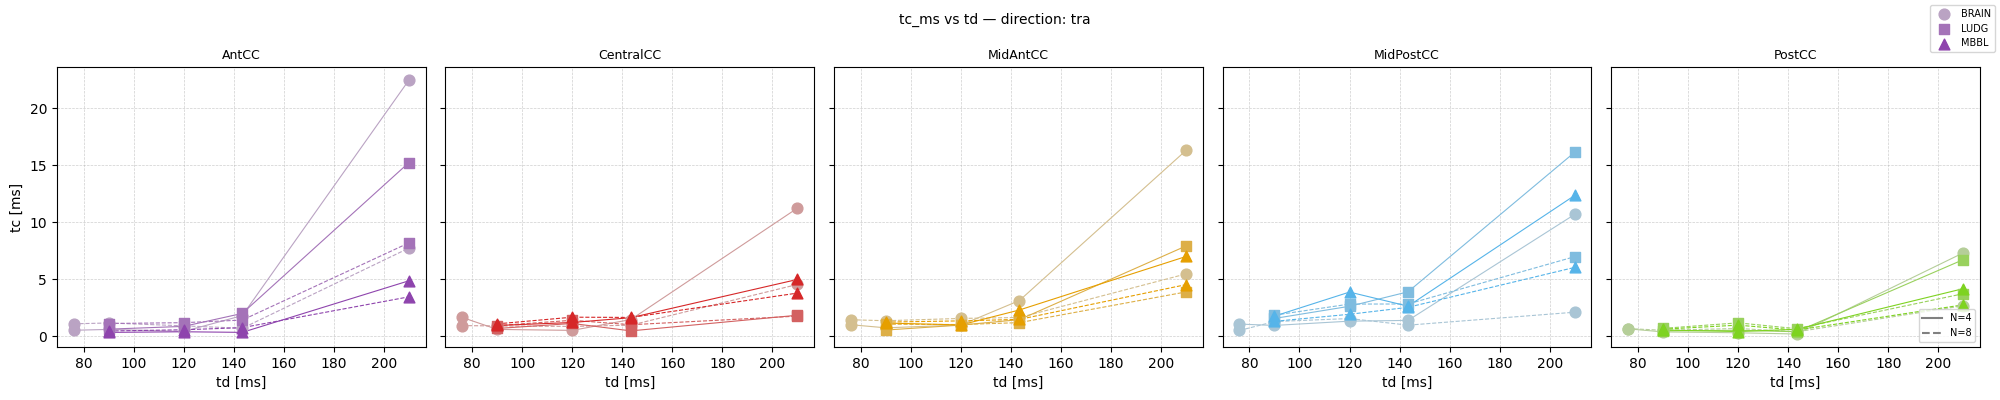

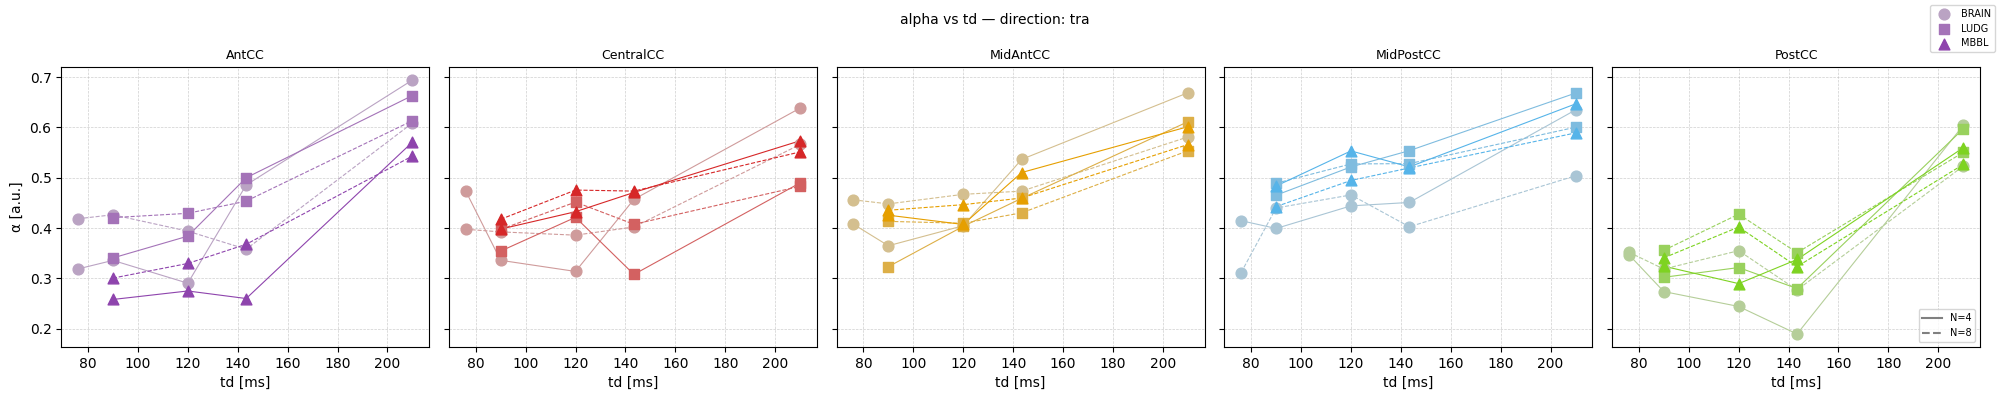

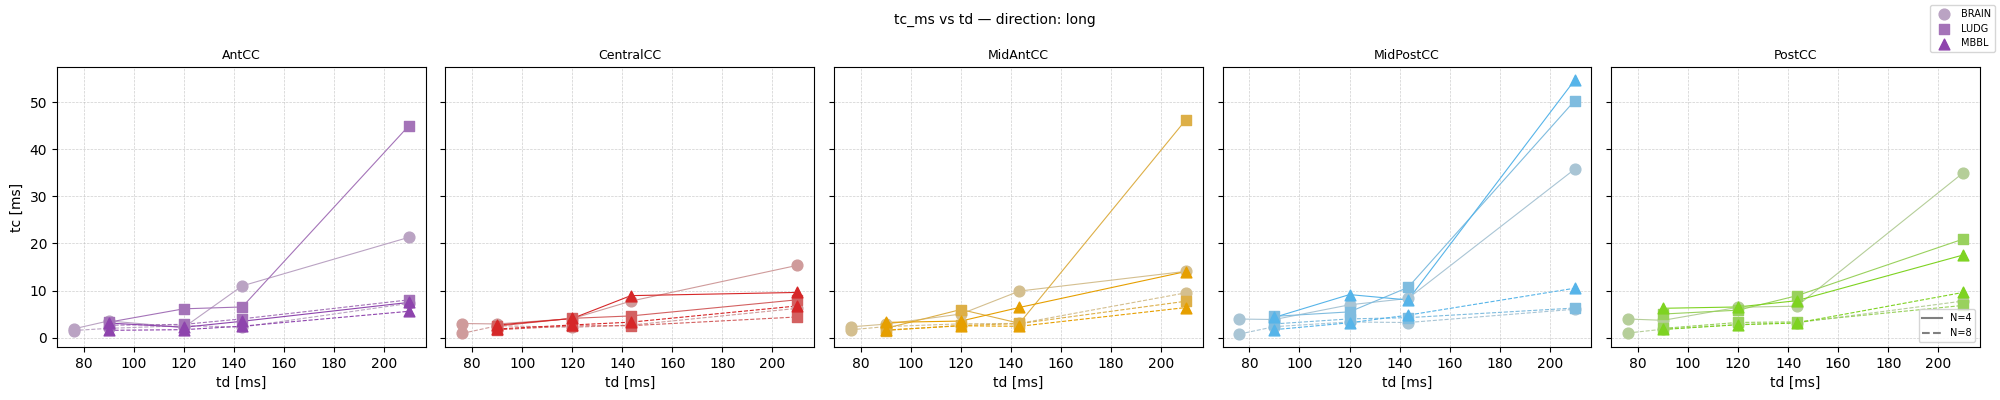

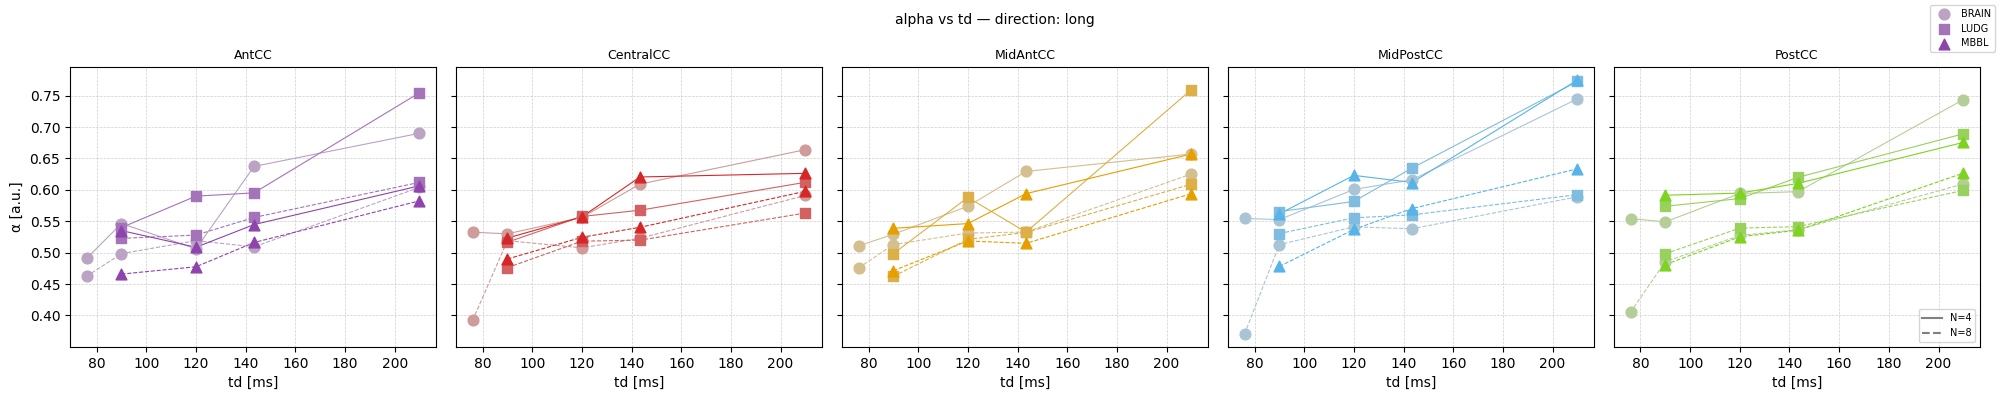

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT tc and α vs td  —  all subjects, grouped by ROI and direction
# One figure per (param, direction); one panel per ROI
# Colour = subject (lighter → darker within ROI palette), linestyle = N
# ══════════════════════════════════════════════════════════════════════════════

rois     = sorted(results_df.roi.unique())
subjects = sorted(results_df.subj.unique())
roi_colors   = _roi_color_map(rois)
_N_ls        = ["-", "--", "-.", ":"]
N_linestyles = {N: ls for N, ls in zip(N_LIST, _N_ls)}

for direction in DIRECTIONS:
    sub = results_df[results_df.direction == direction]
    for param, ylabel in [("tc_ms", "tc [ms]"), ("alpha", "α [a.u.]")]:
        fig, axes = plt.subplots(1, len(rois), figsize=(4 * len(rois), 4), sharey=True)
        axes = np.atleast_1d(axes)

        for ax, roi in zip(axes, rois):
            base_color = roi_colors[roi]
            cmap = mcolors.LinearSegmentedColormap.from_list("", ["#cccccc", base_color])
            for i, subj in enumerate(subjects):
                shade  = cmap(0.3 + 0.7 * i / max(1, len(subjects) - 1))
                marker = DEFAULT_BRAIN_MARKERS[i % len(DEFAULT_BRAIN_MARKERS)]
                for N in N_LIST:
                    g = (
                        sub[(sub.roi == roi) & (sub.subj == subj) & (sub.N == N)]
                        .drop_duplicates("td_ms").sort_values("td_ms")
                    )
                    if g.empty:
                        continue
                    label = subj if N == N_LIST[0] else None
                    ax.scatter(g.td_ms, g[param], color=shade, marker=marker, s=60, zorder=3, label=label)
                    ax.plot(g.td_ms, g[param], color=shade, linewidth=0.8,
                            linestyle=N_linestyles[N])
            ax.set_title(roi, fontsize=9)
            ax.set_xlabel("td [ms]")
            ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
            ax.set_axisbelow(True)

        axes[0].set_ylabel(ylabel)
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, fontsize=7, loc="upper right", ncol=1)
        n_handles = [mlines.Line2D([], [], color="gray", linestyle=N_linestyles[N], label=f"N={N}") for N in N_LIST]
        axes[-1].legend(handles=n_handles, fontsize=7, loc="lower right")
        fig.suptitle(f"{param} vs td — direction: {direction}", fontsize=10)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"{param}_vs_td_{direction}.png", dpi=120)
        # plt.show()
        # plt.close(fig)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT NORMALIZED FITS  —  S_mixed(tc, α, G) with M0 = 1, no Rician correction
# Useful to compare model shape across subjects/ROIs without amplitude effects
# Data is divided by fitted M0; model plotted as pure S_mixed ∈ [0, 1]
# ══════════════════════════════════════════════════════════════════════════════

for (subj, roi, direction), store in fit_store.items():
    tds   = store["tds"]
    n_tds = len(tds)

    fig, axes_grid = plt.subplots(2, n_tds, figsize=(4 * n_tds, 7), sharey="row", squeeze=False)
    axes      = axes_grid[0]
    diff_axes = axes_grid[1]

    for ax, dax, td in zip(axes, diff_axes, tds):
        fits_td = store["fits"][td]
        y_hat_per_N = {}
        for N, color in zip(N_LIST, ["C0", "C1", "C2", "C3"]):
            fit = fits_td.get(N)
            if fit is None:
                continue
            M0 = fit["M0"] if fit["M0"] != 0.0 else 1.0
            RN = fit["RN"]
            y_corr = np.sqrt(np.abs(fit["y"]**2 - RN**2)) * np.sign(fit["y"]**2 - RN**2) / M0
            ax.scatter(fit["G"], y_corr, color=color, s=20, zorder=3, label=f"N={N} data corr")
            with np.errstate(over="ignore", invalid="ignore"):
                sig_norm = M_ogse_mixed_offset(td, G_plot, N, td / N, fit["tc"], fit["alpha"], 1.0, D0_FIXED, 0, 0)
            y_hat_per_N[N] = sig_norm
            ax.plot(G_plot, sig_norm, color=color, label=f"N={N} model")
        ax.set_title(f"td = {td:.1f} ms", fontsize=8)
        ax.set_xlabel(G_LABEL)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        if N_hi in y_hat_per_N and N_lo in y_hat_per_N:
            dax.plot(G_plot, y_hat_per_N[N_hi] - y_hat_per_N[N_lo], color="k")
            dax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
        dax.set_title(f"td = {td:.1f} ms  (N={N_hi} − N={N_lo})", fontsize=8)
        dax.set_xlabel(G_LABEL)
        dax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        dax.set_axisbelow(True)

    axes[0].set_ylabel(f"{Y_COLUMN} / M0 [a.u.]")
    diff_axes[0].set_ylabel(f"ΔS  (N={N_hi} − N={N_lo})")
    axes[0].legend(fontsize=6)
    fig.suptitle(f"{subj}  |  {roi}  |  {direction}  |  S_mixed (no RN)", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_norm_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Normalized model plots saved.")

Normalized model plots saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT tc, α and M0 vs td  —  per subject
# Rows = ROIs, columns = directions, colour/linestyle = N
# Shaded band = ±1σ from the Jacobian covariance
# ══════════════════════════════════════════════════════════════════════════════

subjects_plot = sorted(results_df.subj.unique())
rois_plot     = sorted(results_df.roi.unique())
Ns_plot       = sorted(results_df.N.unique())
dirs_plot     = [d for d in ["long", "tra"] if d in results_df.direction.unique()]
_N_ls_p       = ["-", "--", "-.", ":"]
N_ls          = {N: _N_ls_p[i % len(_N_ls_p)] for i, N in enumerate(Ns_plot)}

for subj in subjects_plot:
    for param, ylabel in [("tc_ms", "tc [ms]"), ("alpha", "α [a.u.]"), ("M0", "M0 [a.u.]")]:
        fig, axes = plt.subplots(
            len(rois_plot), len(dirs_plot),
            figsize=(4 * len(dirs_plot), 3 * len(rois_plot)),
            sharey=False, squeeze=False,
        )
        for i_roi, roi in enumerate(rois_plot):
            for i_dir, direction in enumerate(dirs_plot):
                ax = axes[i_roi, i_dir]
                s = results_df[
                    (results_df.subj == subj) &
                    (results_df.roi == roi) &
                    (results_df.direction == direction)
                ]
                for N in Ns_plot:
                    g = s[s.N == N].sort_values("td_ms")
                    if g.empty:
                        continue
                    line, = ax.plot(g.td_ms, g[param], linestyle=N_ls[N],
                                    marker="o", ms=4, linewidth=0.8, label=f"N={N}")
                    err_col = f"{param}_err"
                    if err_col in g.columns:
                        x    = g.td_ms.to_numpy(dtype=float)
                        yv   = g[param].to_numpy(dtype=float)
                        yerr = g[err_col].to_numpy(dtype=float)
                        ok   = np.isfinite(x) & np.isfinite(yv) & np.isfinite(yerr)
                        if np.any(ok):
                            ax.fill_between(x[ok], yv[ok] - yerr[ok], yv[ok] + yerr[ok],
                                            color=line.get_color(), alpha=0.18, linewidth=0)
                if i_roi == 0:
                    ax.set_title(direction, fontsize=9)
                if i_dir == 0:
                    ax.set_ylabel(f"{roi}\n{ylabel}", fontsize=8)
                ax.set_xlabel("td [ms]")
                ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
                ax.set_axisbelow(True)
                if i_roi == 0 and i_dir == len(dirs_plot) - 1:
                    ax.legend(fontsize=6, title="N", title_fontsize=6)
        fig.suptitle(f"{subj} — {param} vs td", fontsize=11)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"{param}_vs_td_{subj}.png", dpi=120)
        plt.close(fig)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT tc, α and M0 vs td  —  per subject, log-scale y-axis
# Same layout as previous cell; useful to spot order-of-magnitude variation
# ══════════════════════════════════════════════════════════════════════════════

for subj in subjects_plot:
    for param, ylabel in [("tc_ms", "tc [ms]"), ("alpha", "α [a.u.]"), ("M0", "M0 [a.u.]")]:
        fig, axes = plt.subplots(
            len(rois_plot), len(dirs_plot),
            figsize=(4 * len(dirs_plot), 3 * len(rois_plot)),
            sharey=False, squeeze=False,
        )
        for i_roi, roi in enumerate(rois_plot):
            for i_dir, direction in enumerate(dirs_plot):
                ax = axes[i_roi, i_dir]
                s = results_df[
                    (results_df.subj == subj) &
                    (results_df.roi == roi) &
                    (results_df.direction == direction)
                ]
                for N in Ns_plot:
                    g = s[s.N == N].sort_values("td_ms")
                    if g.empty:
                        continue
                    line, = ax.plot(g.td_ms, g[param], linestyle=N_ls[N],
                                    marker="o", ms=4, linewidth=0.8, label=f"N={N}")
                    err_col = f"{param}_err"
                    if err_col in g.columns:
                        x     = g.td_ms.to_numpy(dtype=float)
                        yv    = g[param].to_numpy(dtype=float)
                        yerr  = g[err_col].to_numpy(dtype=float)
                        lower = np.maximum(yv - yerr, np.finfo(float).tiny)
                        upper = yv + yerr
                        ok    = np.isfinite(x) & np.isfinite(yv) & np.isfinite(yerr) & (yv > 0) & (upper > 0)
                        if np.any(ok):
                            ax.fill_between(x[ok], lower[ok], upper[ok],
                                            color=line.get_color(), alpha=0.18, linewidth=0)
                ax.set_yscale("log")
                if i_roi == 0:
                    ax.set_title(direction, fontsize=9)
                if i_dir == 0:
                    ax.set_ylabel(f"{roi}\n{ylabel} (log)", fontsize=8)
                ax.set_xlabel("td [ms]")
                ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
                ax.set_axisbelow(True)
                if i_roi == 0 and i_dir == len(dirs_plot) - 1:
                    ax.legend(fontsize=6, title="N", title_fontsize=6)
        fig.suptitle(f"{subj} — {param} vs td  (log scale)", fontsize=11)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"{param}_vs_td_log_{subj}.png", dpi=120)
        plt.close(fig)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT SIGNAL CONTRAST  ΔS = S(N_hi) − S(N_lo)  vs G, Ld, Lcf, lcf
# Per subject: rows = ROIs, columns = directions, colour = td
# "_raw"  uses the full model:  sqrt( M0²·S_mixed² + RN² )
# "_corr" uses the clean model: M0·S_mixed(tc, α, G)  (no Rician term)
# ══════════════════════════════════════════════════════════════════════════════

td_cmap    = plt.cm.viridis
N_hi, N_lo = N_LIST[-1], N_LIST[0]
G_plot     = np.linspace(0, float(data.G_fit.max()), 300)
PEAK_GAMMA = 267.5221900   # rad / (ms · mT), proton gyromagnetic ratio

def _x_for_td(td_ms, xvar):
    if xvar == "G":
        return G_plot.copy()
    D0, gamma = float(D0_PLOT), float(PEAK_GAMMA)
    l_d = np.sqrt(D0 * float(td_ms))
    l_G = np.full_like(G_plot, np.nan)
    valid = G_plot > 0
    l_G[valid] = (D0 / (gamma * G_plot[valid])) ** (1.0 / 3.0)
    Ld  = l_d / l_G
    Lcf = 1.5 ** 0.25 / np.sqrt(Ld)
    lcf = Lcf * l_G * 1e6
    if xvar == "Ld":  return Ld
    if xvar == "Lcf_a": return Lcf
    if xvar == "lcf": return lcf
    raise ValueError(xvar)

X_AXES = [
    ("G",   G_LABEL),
    ("Ld",  "Lᵈ (dimensionless)"),
    ("Lcf_a", "Lcf (dimensionless)"),
    ("lcf", "lcf [µm]"),
]

X_LIMITS = {
    "Lcf_a": (0.5, 1.4),
    "lcf": (0, 35),
}

D0_PLOT = D0_FIXED

# ── precompute contrasts ───────────────────────────────────────────────────────
raw_contrast_store  = {}   # sqrt(sig² + rn²)
corr_contrast_store = {}   # sig only

for (subj, roi, direction), store in fit_store.items():
    for td in store["tds"]:
        raw_per_N  = {}
        corr_per_N = {}
        for N in N_LIST:
            fit = store["fits"][td].get(N)
            if fit is None:
                continue
            rn = fit.get("RN", 0.0)
            with np.errstate(over="ignore", invalid="ignore"):
                sig   = M_ogse_mixed_offset(td, G_plot, N, td / N, fit["tc"], fit["alpha"], 1, D0_FIXED, 0, 0)
                y_hat = np.sqrt( sig**2 + (rn**2)/(fit["M0"]**2) ) if rn != 0.0 else sig
            raw_per_N[N]  = y_hat
            corr_per_N[N] = sig
        if N_hi in raw_per_N and N_lo in raw_per_N:
            raw_contrast_store[(subj, roi, direction, td)]  = raw_per_N[N_hi]  - raw_per_N[N_lo]
        if N_hi in corr_per_N and N_lo in corr_per_N:
            corr_contrast_store[(subj, roi, direction, td)] = corr_per_N[N_hi] - corr_per_N[N_lo]

# ── precompute free (unrestricted) contrast, same D0 as the other models ─────
free_contrast_store = {}

for (subj, roi, direction), store in fit_store.items():
    for td in store["tds"]:
        with np.errstate(over="ignore", invalid="ignore"):
            sig_hi = M_ogse_free(td, G_plot, N_hi, td / N_hi, 1, D0_FIXED)
            sig_lo = M_ogse_free(td, G_plot, N_lo, td / N_lo, 1, D0_FIXED)
        free_contrast_store[(subj, roi, direction, td)] = sig_hi - sig_lo

# ── helper ─────────────────────────────────────────────────────────────────────
def _plot_contrast(cstore, xvar, xlabel, subj, suffix, title_tag, free_store=None):
    rois_subj = sorted(set(k[1] for k in cstore if k[0] == subj))
    dirs_subj = [d for d in DIRECTIONS if any(k[2] == d for k in cstore if k[0] == subj)]
    n_rois, n_dirs = len(rois_subj), len(dirs_subj)
    if n_rois == 0 or n_dirs == 0:
        return
    all_tds_subj = sorted(set(k[3] for k in cstore if k[0] == subj))
    colors_leg   = [td_cmap(i / max(1, len(all_tds_subj) - 1)) for i in range(len(all_tds_subj))]
    leg_handles  = [plt.Line2D([0], [0], color=c, linewidth=1.5) for c in colors_leg]
    leg_labels   = [f"td={td:.0f} ms" for td in all_tds_subj]
    td_color_map = {td: c for td, c in zip(all_tds_subj, colors_leg)}
    if free_store is not None:
        leg_handles.append(plt.Line2D([0], [0], color="lightgrey", linestyle=":", linewidth=1.5))
        leg_labels.append("free")
    fig, axes = plt.subplots(n_rois, n_dirs, figsize=(4 * n_dirs, 3 * n_rois), squeeze=False, sharey="row")
    for i_roi, roi in enumerate(rois_subj):
        for i_dir, direction in enumerate(dirs_subj):
            ax = axes[i_roi, i_dir]
            tds_here = sorted(k[3] for k in cstore
                              if k[0] == subj and k[1] == roi and k[2] == direction)
            if not tds_here:
                ax.set_visible(False)
                continue
            for td in tds_here:
                ax.plot(_x_for_td(td, xvar), cstore[(subj, roi, direction, td)],
                        color=td_color_map[td], linewidth=1.2)
                if free_store is not None and (subj, roi, direction, td) in free_store:
                    ax.plot(_x_for_td(td, xvar), free_store[(subj, roi, direction, td)],
                            color="lightgrey", linestyle=":", linewidth=1.2)
            ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
            if i_roi == 0:
                ax.set_title(direction, fontsize=9)
            if i_dir == 0:
                ax.set_ylabel(f"{roi}\nΔS (N={N_hi}−N={N_lo})", fontsize=7)
            ax.set_xlabel(xlabel, fontsize=7)
            ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
            ax.set_axisbelow(True)
            ax.tick_params(labelsize=6)
            # ax.set_ylim(0, 0.5)
            if xvar in X_LIMITS:
                ax.set_xlim(*X_LIMITS[xvar])
            ax.tick_params(axis="y", labelleft=True)
    fig.suptitle(f"{subj} — contrast ΔS (N={N_hi}−N={N_lo}) vs {xvar}  [{title_tag}]", fontsize=10,y=0.995)
    fig.legend(leg_handles, leg_labels,
               loc="upper center", ncol=len(leg_labels), fontsize=7, frameon=False,
               bbox_to_anchor=(0.5, 0.96), bbox_transform=fig.transFigure)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(OUT_DIR / f"contrast_vs_{xvar}_{subj}_{suffix}.png", dpi=120, bbox_inches="tight")
    plt.close(fig)

# ── generate _raw and _corr figures ───────────────────────────────────────────
all_subjs = sorted(set(k[0] for k in raw_contrast_store))
for xvar, xlabel in X_AXES:
    for subj in all_subjs:
        _plot_contrast(raw_contrast_store,  xvar, xlabel, subj, "raw",  "fit w/ RN")
        _plot_contrast(corr_contrast_store, xvar, xlabel, subj, "corr", "clean model", free_store=free_contrast_store)

print("Per-subject contrast figures saved (_raw and _corr).")

Per-subject contrast figures saved (_raw and _corr).
